<a href="https://www.kaggle.com/code/obsinetkumsa/adv-cs1-pbl?scriptVersionId=303905800" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Load data
df = pd.read_csv("/kaggle/input/nba-players-data/all_seasons.csv")

df_master = df.copy()

# Make all player names follow the same structure as the user prompt
df_master["player_name"] = df_master["player_name"].str.lower().str.strip() 

In [3]:
# Prompt user
try: 
    player = input("Select a player (full name): ").strip().lower() # Avoid human error
except:
    player = "lebron james" # default player


# Handle errors if name is not in the column
if not (df_master['player_name'] == player).any():
    raise ValueError(f"{player} not found in the player_name column.")

Select a player (full name):  derrick rose


# Preprocessing

In [4]:
# Starting year of a season
df_master["season_start"] = (
    df_master["season"]
    .astype(str)
    .str.split("-")
    .str[0]
    .astype(float)
)

# Ending year of a season
df_master['season_end'] = df_master['season_start'] + 1

df_master = df_master.rename(columns={'pts': 'ppg'})
  
# New column: the known ppg of a player's next season (label)
df_master["next_season_ppg"] = df_master.groupby("player_name")["ppg"].shift(-1)

# Match next_season_ppg with ppg for each player
df_master = df_master.sort_values(['player_name', 'season_start'])

# Drop rows with no label values (e.g. last season of an NBA player)
df_master = df_master.dropna(subset=['next_season_ppg'])

In [5]:
# Map historical team names to their respective current team name
team_map = {
    "CHH":"CHA",
    "NOH":"NOP",
    "NOK":"NOP",
    "SEA":"OKC",
    "VAN":"MEM",
    "NJN":"BKN"
}
df_master['team_abbreviation'] = df_master['team_abbreviation'].replace(team_map)

# Train/test split

In [6]:
# Manually split by year data to prevent data leakage
training_set = df_master[df_master["season_end"] <= 2016].copy()
test_set = df_master[df_master["season_end"] >= 2017].copy() # Makes about 30% of data

# Model input, drop unnecessary features
X_train = training_set.drop(columns=[
        "next_season_ppg", 
        "player_name", 
        "season_start", 
        "season_end", 
        "college",
        "country", 
        "season", 
        "Unnamed: 0",
        "draft_year",
        "draft_round",
        "draft_number"
])

# Only labels
y_train = training_set["next_season_ppg"]

# 
X_test = test_set.drop(columns=[
        "next_season_ppg", 
        "player_name", 
        "season_start", 
        "season_end", 
        "college",
        "country", 
        "season", 
        "Unnamed: 0",
        "draft_year",
        "draft_round",
        "draft_number"
])

y_test = test_set["next_season_ppg"]

# Pipeline

In [7]:
# Import dependecies 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Define numeric columns
num_columns = [col for col in X_train if X_train[col].dtype in ['int64', 'float64']]

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # median is preferential because of skewed data in features
    ('scaler', StandardScaler())
])

cat_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_columns),
        ('cat', cat_transformer, ['team_abbreviation'])
    ])

In [8]:
# Create model w/ Random Forest
from sklearn.ensemble import RandomForestRegressor
    
model = RandomForestRegressor(random_state=1)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

# Train the model
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'player_height',
                                                   'player_weight', 'gp', 'ppg',
                                                   'reb', 'ast', 'net_rating',
                                                   'oreb_pct', 'dreb_pct',
                                                   'usg_pct', 'ts_pct',
                                                   'ast_pct']),
                                                 ('cat', OneHotEncoder(),
                                                  ['team_abbreviation'])])),
                ('model', RandomForestRegressor(random_state=1))])

In [9]:
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
importance = pipeline.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature_names": feature_names,
    "importance": importance
}).sort_values("importance", ascending=False)

print(feature_importance_df)

                 feature_names  importance
4                     num__ppg    0.751638
0                     num__age    0.035003
7              num__net_rating    0.027786
10                num__usg_pct    0.022827
3                      num__gp    0.020745
11                 num__ts_pct    0.020380
9                num__dreb_pct    0.015586
8                num__oreb_pct    0.015503
12                num__ast_pct    0.015037
2           num__player_weight    0.013414
5                     num__reb    0.011969
6                     num__ast    0.010553
1           num__player_height    0.008318
24  cat__team_abbreviation_IND    0.001666
37  cat__team_abbreviation_POR    0.001624
22  cat__team_abbreviation_GSW    0.001389
26  cat__team_abbreviation_LAL    0.001378
23  cat__team_abbreviation_HOU    0.001325
20  cat__team_abbreviation_DEN    0.001247
30  cat__team_abbreviation_MIN    0.001241
38  cat__team_abbreviation_SAC    0.001188
36  cat__team_abbreviation_PHX    0.001182
40  cat__te

# Iterative forecasting (rolling)

In [10]:
prediction_years = [2017, 2018, 2019, 2020, 2021, 2022, 2023]

X_roll = df_master[df_master["season_end"] == 2016].copy()
X_roll = X_roll.set_index("player_name")
all_preds = []

for year in prediction_years:
    X_roll_model = X_roll.drop(columns=["player_name"], errors="ignore")
    
    y_pred = pipeline.predict(X_roll_model) # predicts following year's stats

    preds = pd.Series(y_pred, index=X_roll.index, name=f"pred_{year}") # create series based on predictions
    all_preds.append(preds) 

    # Roll forward
    X_roll["ppg"] = y_pred
    X_roll["age"] += 1
    
pred_df = pd.concat(all_preds, axis=1) # create a dataframe of all the yearly predictions

# Evaluation

In [11]:
# Evaluate model
from sklearn.metrics import root_mean_squared_error

# Calculate RMSE across all years that were predicted
def yearly_error(test_set , pred_df, prediction_years):
    scores = {}
    test_set = test_set.set_index("player_name")

    for year in prediction_years:
        # Actual values for the corresponding year
        y_true = test_set.loc[
            test_set['season_end'] == year, 'ppg'
        ]

        # Predictions for the corresponding year
        y_pred = pred_df[f"pred_{year}"]

        # only include players in both series
        y_true_aligned, y_pred_aligned = y_true.align(
            y_pred, join = "inner"
        )

        # If no player stats exist in the true set, skip the year
        if len(y_true_aligned) == 0:
            continue
        
        scores[year] = root_mean_squared_error(y_true_aligned, y_pred_aligned)
        
    return scores
        
print(yearly_error(test_set, pred_df, prediction_years))

{2017: 1.1495121068744476, 2018: 3.313944017555598, 2019: 4.150796371505005, 2020: 4.608387969093337, 2021: 5.500292600608415, 2022: 5.475967903204243}


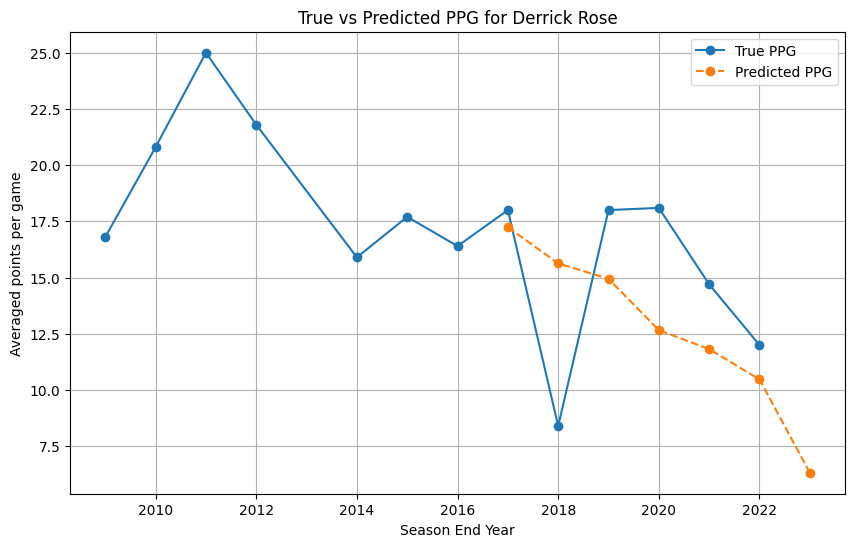

In [12]:
import matplotlib.pyplot as plt

true_ppg = (
    df_master[df_master["player_name"] == player]
    .sort_values("season_end")[["season_end", "ppg"]]
)

pred_ppg = (
    pred_df.loc[player]
    .rename(lambda x: int(x.split("_")[1]))
    .reset_index()
)
pred_ppg.columns = ["season_end", "pred_ppg"]

plt.figure(figsize=(10,6))

plt.plot(
    true_ppg["season_end"],
    true_ppg["ppg"],
    marker="o",
    label="True PPG"
)

plt.plot(
    pred_ppg["season_end"],
    pred_ppg["pred_ppg"],
    marker="o",
    linestyle="--",
    label="Predicted PPG"
)

plt.xlabel("Season End Year")
plt.ylabel("Averaged points per game")

player = player.title()
plt.title(f"True vs Predicted PPG for {player}")
plt.legend()
plt.grid(True)

plt.show()
